In [ ]:
# Import required libraries for machine learning and data analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For data manipulation with dataframes
from sklearn.model_selection import train_test_split  # For splitting data into train and test sets
from sklearn.preprocessing import MinMaxScaler  # For feature scaling (0-1 normalization)
from sklearn.linear_model import LogisticRegression  # For logistic regression classification model
from sklearn.ensemble import IsolationForest  # For anomaly detection and outlier removal
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score, precision_recall_curve,auc  # For model evaluation metrics
import matplotlib.pyplot as plt  # For plotting visualizations
# Set pandas display options to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

### Load Model Input Data

In [ ]:
# Read the processed model input data from CSV file
df=pd.read_csv("../Model_Input_Data/Model_Input_Data.csv")
# Print the dimensions (rows and columns) of the dataset
print(df.shape)
# Display the first 5 rows of the dataset
df.head()

(5410, 36)


,Provider,PotentialFraud,IP_Claim_Count,IP_Benf_Count,Avg_IP_InscClaimAmtReimbursed,Avg_IP_DeductibleAmtPaid,Avg_IP_Number_of_Days_in_Hospital,Avg_IP_Number_of_Days_in_Hospital.1,Avg_IP_Number_of_Days_in_Hospital.2,Avg_IP_Number_of_Days_in_Hospital.3,OP_Claim_Count,OP_Benf_Count,Avg_OP_InscClaimAmtReimbursed,Avg_OP_DeductibleAmtPaid,Avg_OP_Number_of_Days_in_Hospital,Avg_OP_Number_of_Days_in_Hospital.1,Avg_OP_Number_of_Days_in_Hospital.2,Total_Beneficiaries,RenalDisease_Count,Alzheimer_Count,HeartFailure_Count,KidneyDisease_Count,Cancer_Count,Pulmonary_Count,Depression_Count,Diabetes_Count,IschemicHeart_Count,Osteoporosis_Count,RheumatoidArthritis_Count,Stroke_Count,Avg_PartA_Months,Avg_PartB_Months_Mode,Avg_IP_Reimbursement,Avg_IP_Deductible,Avg_OP_Reimbursement,Avg_OP_Deductible
0,PRV51001,0,5,5,19400.000000,1068.0,0.0,0.0,6.0,0.0,20,19,382.000000,0.000000,0.0,1.0,0.0,24,8,10,6,7,19,15,15,4,2,18,16,19,12,12,18047.916667,890.000000,2537.500000,474.916667
1,PRV51003,1,62,53,9241.935484,1068.0,3.0,3.0,9.0,1.0,70,66,466.714286,1.000000,0.0,1.0,0.0,117,22,73,47,65,107,84,70,30,18,89,85,108,12,12,6814.017094,822.632479,2490.598291,664.529915
2,PRV51004,0,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,149,138,350.134228,2.080537,0.0,1.0,0.0,138,20,78,56,91,122,101,78,42,40,95,97,122,12,12,4596.739130,454.144928,2095.144928,600.869565
3,PRV51005,1,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,1165,495,241.124464,3.175966,0.0,1.0,0.0,495,79,330,232,317,436,390,311,181,148,353,368,456,12,12,3717.232323,398.698990,1798.808081,475.965657
4,PRV51007,0,3,3,6333.333333,1068.0,4.0,4.0,6.0,0.0,69,56,213.188406,0.869565,0.0,1.0,0.0,58,9,37,28,41,52,46,37,22,18,41,42,49,12,12,3109.655172,423.517241,1497.241379,430.689655


In [ ]:
# Display the count distribution of the target variable (PotentialFraud) to check class imbalance
df.PotentialFraud.value_counts()

PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Here The data was Imbalanced.

### Checking Correlation Coefficent

- build a correlation matrix.
- identify Higly correlated variables.

In [ ]:
# Compute correlation matrix for all numeric features excluding the Provider column
corr_matrix=df.iloc[:,1:].corr()
# Display the first 5 rows and columns of the correlation matrix
corr_matrix.head()

,PotentialFraud,IP_Claim_Count,IP_Benf_Count,Avg_IP_InscClaimAmtReimbursed,Avg_IP_DeductibleAmtPaid,Avg_IP_Number_of_Days_in_Hospital,Avg_IP_Number_of_Days_in_Hospital.1,Avg_IP_Number_of_Days_in_Hospital.2,Avg_IP_Number_of_Days_in_Hospital.3,OP_Claim_Count,OP_Benf_Count,Avg_OP_InscClaimAmtReimbursed,Avg_OP_DeductibleAmtPaid,Avg_OP_Number_of_Days_in_Hospital,Avg_OP_Number_of_Days_in_Hospital.1,Avg_OP_Number_of_Days_in_Hospital.2,Total_Beneficiaries,RenalDisease_Count,Alzheimer_Count,HeartFailure_Count,KidneyDisease_Count,Cancer_Count,Pulmonary_Count,Depression_Count,Diabetes_Count,IschemicHeart_Count,Osteoporosis_Count,RheumatoidArthritis_Count,Stroke_Count,Avg_PartA_Months,Avg_PartB_Months_Mode,Avg_IP_Reimbursement,Avg_IP_Deductible,Avg_OP_Reimbursement,Avg_OP_Deductible
PotentialFraud,1.000000,0.525393,0.522256,0.307556,0.319855,0.156278,0.157271,0.332043,0.203341,0.335803,0.340550,0.046770,0.041701,-0.005206,-0.058295,0.042329,0.393531,0.409965,0.386035,0.376435,0.375876,0.391582,0.381486,0.387190,0.375898,0.369433,0.390565,0.388635,0.389683,0.009770,0.008369,0.127398,0.119897,-0.015204,-0.031547
IP_Claim_Count,0.525393,1.000000,0.997492,0.327985,0.398766,0.223728,0.224221,0.418265,0.228004,0.208758,0.276037,0.049353,0.041827,-0.003967,-0.059130,0.049632,0.391992,0.443241,0.367057,0.346287,0.347629,0.385222,0.358068,0.370984,0.336251,0.325412,0.383660,0.379031,0.382209,0.009087,0.007868,0.165848,0.183794,-0.023449,-0.028603
IP_Benf_Count,0.522256,0.997492,1.000000,0.336416,0.409007,0.229987,0.230475,0.428677,0.231378,0.208244,0.278841,0.047527,0.040143,-0.004631,-0.062674,0.048281,0.395842,0.448558,0.370378,0.349185,0.350732,0.388839,0.361502,0.374276,0.338844,0.328001,0.387186,0.382511,0.386015,0.009265,0.008031,0.170824,0.189412,-0.023422,-0.028680
Avg_IP_InscClaimAmtReimbursed,0.307556,0.327985,0.336416,1.000000,0.839577,0.672207,0.671091,0.827822,0.578765,0.022452,0.039578,0.001402,-0.002840,-0.027280,-0.189112,0.015028,0.081826,0.103559,0.072955,0.063288,0.064599,0.079234,0.069923,0.074579,0.061251,0.057874,0.079036,0.077457,0.078331,0.005905,0.010255,0.478656,0.411210,-0.007450,-0.026045
Avg_IP_DeductibleAmtPaid,0.319855,0.398766,0.409007,0.839577,1.000000,0.661765,0.662139,0.976286,0.566851,0.028770,0.052258,-0.001592,-0.005470,-0.033019,-0.217772,0.017184,0.103420,0.129415,0.092288,0.081232,0.082823,0.100502,0.088882,0.094274,0.077895,0.074164,0.099966,0.097892,0.099275,-0.000936,0.003250,0.396898,0.433707,-0.029665,-0.042322


In [ ]:
# Get list of all column names from the correlation matrix
cols = corr_matrix.columns
# For each row, find variables with correlation between 0.8 and 1.0 (excluding self-correlation at 1.0)
corr_matrix['check'] = corr_matrix.apply(lambda row : [c for c in cols if 0.8<=abs(row[c])<1 ])

In [176]:
#corr_matrix[['check']]

### Train, Test Split

In [ ]:
# Prepare features by dropping non-predictive columns (Provider ID and target variable)
X_var = df.drop(columns = ['Provider','PotentialFraud'] )
# Extract the target variable for fraud prediction
y_var = df['PotentialFraud']
# Split data into training (80%) and test (20%) sets with stratified sampling to maintain class distribution
x_train,x_test,y_train,y_test = train_test_split(X_var,y_var,test_size = 0.2, stratify = y_var, random_state = 42)

In [ ]:
# Print the shape of training data (rows, columns)
print(x_train.shape)
# Print the shape of test data (rows, columns)
print(x_test.shape)

(4328, 34)
(1082, 34)


In [ ]:
# Display the count distribution of the target variable in training set
print(y_train.value_counts())

PotentialFraud
0    3923
1     405
Name: count, dtype: int64


In [ ]:
# Display the count distribution of the target variable in test set
print(y_test.value_counts())

PotentialFraud
0    981
1    101
Name: count, dtype: int64


### Outlier Removal

In [ ]:
# Print the shape of the training data before outlier removal
print(x_train.shape)
# Initialize Isolation Forest with 0.5% contamination rate (to detect 0.5% of data as outliers)
clf = IsolationForest(contamination= 0.005)
# Combine features and target variable into a single dataframe for outlier detection
outlier_removal_df = pd.concat([x_train,y_train],axis = 1).reset_index(drop = True)
# Fit the Isolation Forest model on the combined data
clf.fit(outlier_removal_df)
# Get predictions: 1 for inliers, -1 for outliers
predictions = clf.predict(outlier_removal_df)
# Keep only the rows where predictions equal 1 (inliers) and reset index
x_train_cleaned = outlier_removal_df[np.where(predictions == 1, True, False)].reset_index(drop = True).copy()
# Extract features from the cleaned data
x_train = x_train_cleaned.drop(columns = 'PotentialFraud')
# Extract target from the cleaned data
y_train = x_train_cleaned['PotentialFraud']
# Print the shape of training data after outlier removal
print(x_train.shape)

(4328, 34)
(4306, 34)


In [ ]:
# Display the shape of the cleaned training data
x_train_cleaned.shape

(4306, 35)

In [ ]:
# Display the count distribution of target variable in test set (after cleaning)
y_test.value_counts()

PotentialFraud
0    981
1    101
Name: count, dtype: int64

### Scaling

In [ ]:
# Initialize MinMaxScaler to scale features to the range [0, 1]
scaler=MinMaxScaler()
# Fit the scaler on training data and apply the transformation
x_train=scaler.fit_transform(x_train)
# Apply the same transformation to test data (using parameters learned from training data)
x_test=scaler.transform(x_test)

### Loading Logistic Regression Model

In [ ]:
# Initialize Logistic Regression model with maximum iterations set to 1000
lr_estimate = LogisticRegression(max_iter = 1000,  # Maximum iterations for convergence
                                # penalty = 'l1',  # (Optional) L1 regularization
                                 #solver = 'liblinear',  # (Optional) Solver type
                                 #C = 1.8,  # (Optional) Inverse regularization strength
                                #class_weight={0:0.35,1:0.65},  # (Optional) Class weights for handling imbalance
                                random_state = 42)  # Random seed for reproducibility
# Train the logistic regression model on scaled training data
lr_estimate.fit(x_train,y_train)
# Make binary predictions (0 or 1) on the test set
y_pred = lr_estimate.predict(x_test)
# Get predicted probabilities for the positive class (fraud probability)
y_prob = lr_estimate.predict_proba(x_test)[:, 1]
# Print classification metrics report showing precision, recall, and f1-score
print("*****Classification Rport********")
print(classification_report(y_test,y_pred))
# Print confusion matrix showing true/false positives and negatives
print("**** Confusion Matrix ***********")
print(confusion_matrix(y_test,y_pred))

*****Classification Rport********
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       981
           1       0.82      0.45      0.58       101

    accuracy                           0.94      1082
   macro avg       0.88      0.72      0.77      1082
weighted avg       0.93      0.94      0.93      1082

**** Confusion Matrix ***********
[[971  10]
 [ 56  45]]


In [ ]:
# Print the number of iterations used for model convergence
print(lr_estimate.n_iter_)

[38]


In [ ]:
# Calculate accuracy score on the training data
Train_score = accuracy_score(y_train,lr_estimate.predict(x_train))
# Calculate accuracy score on the test data
Test_score = accuracy_score(y_test,y_pred)
# Print training set accuracy
print("Train_score: ", Train_score)
# Print test set accuracy
print("Test_score: ", Test_score)
# Calculate and print the overfitting percentage (difference between train and test accuracy)
print("over_fiting: ", (Train_score - Test_score)*100)

Train_score:  0.9277751973989782
Test_score:  0.9390018484288355
over_fiting:  -1.1226651029857315


In [ ]:
# Extract coefficients from the trained logistic regression model
coefficients = lr_estimate.coef_[0]

# Create a dataframe showing feature names and their coefficients
feature_importance = pd.DataFrame({
    'Feature': X_var.columns,  # Feature names from the original dataframe
    'Coefficient': coefficients,  # Coefficient values
    'abs_Coefficients': abs(coefficients)  # Absolute values for sorting
})
# Sort the dataframe by absolute coefficient values in descending order (most important features first)
feature_importance = feature_importance.sort_values(by = 'abs_Coefficients', ascending = False)

In [ ]:
# Display the feature importance dataframe with coefficients and absolute coefficients
feature_importance

,Feature,Coefficient,abs_Coefficients
0,IP_Claim_Count,4.866735,4.866735
1,IP_Benf_Count,4.295371,4.295371
8,OP_Claim_Count,2.916748,2.916748
2,Avg_IP_InscClaimAmtReimbursed,2.685933,2.685933
4,Avg_IP_Number_of_Days_in_Hospital,-1.630587,1.630587
5,Avg_IP_Number_of_Days_in_Hospital.1,-1.536489,1.536489
3,Avg_IP_DeductibleAmtPaid,1.202288,1.202288
9,OP_Benf_Count,-1.148629,1.148629
6,Avg_IP_Number_of_Days_in_Hospital.2,0.884915,0.884915
23,Diabetes_Count,0.810047,0.810047


### ROC and PR Curves

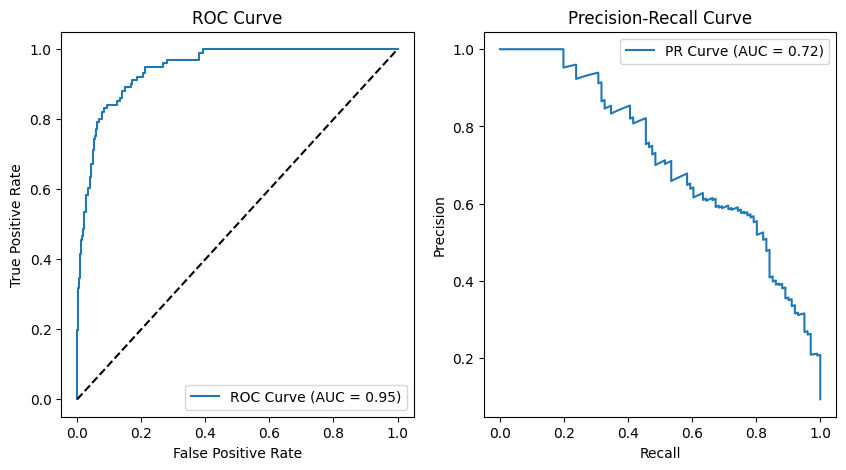

In [ ]:
# Calculate false positive rate and true positive rate for ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate area under the ROC curve (AUC-ROC score)
roc_auc = auc(fpr, tpr)

# Calculate precision and recall values for Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
# Calculate area under the Precision-Recall curve
pr_auc = auc(recall, precision)

# Create a figure with two subplots side by side
plt.figure(figsize=(10, 5))
# Plot ROC Curve in the first subplot
plt.subplot(1, 2, 1)
# Plot the ROC curve line with AUC score in legend
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--')
# Label x-axis
plt.xlabel('False Positive Rate')
# Label y-axis
plt.ylabel('True Positive Rate')
# Set plot title
plt.title('ROC Curve')
# Add legend
plt.legend()

# Plot Precision-Recall Curve in the second subplot
plt.subplot(1, 2, 2)
# Plot the PR curve line with AUC score in legend
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
# Label x-axis
plt.xlabel('Recall')
# Label y-axis
plt.ylabel('Precision')
# Set plot title
plt.title('Precision-Recall Curve')
# Add legend
plt.legend()
# Display the plots
plt.show()